In [1]:
from IPython import get_ipython
ipython = get_ipython()
if ipython is not None:
    ipython.run_line_magic('load_ext', 'autoreload')
    ipython.run_line_magic('autoreload', '2')
else:
    print("could not load extension")

In [2]:
%reload_ext autoreload

In [3]:
import getpass

user = getpass.getuser()
import isaacsim
from omni.isaac.kit import SimulationApp

# Set the path below to your desired nucleus server
# Make sure you installed a local nucleus server before this
# and that isaacsim is running
simulation_app = SimulationApp({"livesync_usd": f"omniverse://localhost/Users/{user}/test.usd"})

Starting kit application with the following args:  ['/home/ubuntu/.local/share/ov/pkg/isaac-sim-4.2.0/exts/omni.isaac.kit/omni/isaac/kit/simulation_app.py', '/home/ubuntu/.local/share/ov/pkg/isaac-sim-4.2.0/apps/omni.isaac.sim.python.kit', '--/app/tokens/exe-path=/home/ubuntu/.local/share/ov/pkg/isaac-sim-4.2.0/kit', '--/persistent/app/viewport/displayOptions=3094', '--/rtx/materialDb/syncLoads=True', '--/rtx/hydra/materialSyncLoads=True', '--/omni.kit.plugin/syncUsdLoads=True', '--/app/renderer/resolution/width=1280', '--/app/renderer/resolution/height=720', '--/app/window/width=1440', '--/app/window/height=900', '--/renderer/multiGpu/enabled=True', '--/app/fastShutdown=False', '--ext-folder', '/home/ubuntu/.local/share/ov/pkg/isaac-sim-4.2.0/exts', '--ext-folder', '/home/ubuntu/.local/share/ov/pkg/isaac-sim-4.2.0/apps', '--/physics/cudaDevice=0', '--portable', '--no-window', '--/app/window/hideUi=1']
Passing the following args to the base kit application:  ['-f', '/home/ubuntu/.local

In [6]:
import carb
from omni.physx import get_physx_scene_query_interface  # for raycasting e.g raycast_closest()
from omni.isaac.core import World
from omni.isaac.core.objects import DynamicCuboid, DynamicSphere, DynamicCone
from omni.timeline import get_timeline_interface
from omni.isaac.core.utils.stage import get_current_stage
import omni.isaac.core.utils.prims as prims_utils
from omni.usd import get_prim_at_path
import omni.isaac.core.utils.rotations as rotations_utils
import omni.isaac.core.utils.mesh as mesh_utils

import numpy as np
import matplotlib.pyplot as plt
from pprint import pprint

In [7]:
def adjust_light(stage, position, intensity=3e9, radius=0.01):
    """
    Adjusts the properties of the first SphereLight found in the given stage.

    Parameters:
    stage (Usd.Stage): The stage containing the lights.
    position (tuple): A tuple representing the new position (x, y, z) of the light.
    intensity (float, optional): The new intensity of the light. Default is 3e9.
    radius (float, optional): The new radius of the light. Default is 0.01.

    Returns:
        None
    """
    lights = []
    for prim in stage.Traverse():
        if prim.GetTypeName() == "SphereLight":
            lights.append(prim)
    if lights:
        light = lights[0]
        light_path = light.GetPath()
        # Adjust position
        translate_attr = stage.GetPrimAtPath(light_path).GetAttribute(
            "xformOp:translate"
        )
        translate_attr.Set(position)
        # Adjust intensity
        intensity_attr = stage.GetPrimAtPath(light_path).GetAttribute(
            "inputs:intensity"
        )
        intensity_attr.Set(intensity)
        # Adjust radius
        radius_attr = stage.GetPrimAtPath(light_path).GetAttribute("inputs:radius")
        radius_attr.Set(0.01)



# Setup Simple Scene
Sun + Flat Plane (lunar surface) + Solar Panel

In [8]:
world = World(stage_units_in_meters=1.0)
stage = get_current_stage()

In [9]:
world.clear()
# world.scene.add_default_ground_plane()
# A render/ step or an update call is needed to reflect the changes to the opened USD in Isaac Sim GUI
#  Note: avoid pressing play/ pause or stop in the GUI in this workflow.
world.render()

In [10]:
# Create the Sun
sun = prims_utils.create_prim(
    "/World/Sun",
    "SphereLight",
    position=np.array([1.0, 1.0, 1.0]),
    attributes={
        "inputs:radius": 1,
        "inputs:intensity": 5e3,
        "inputs:color": (1.0, 1.0, 1.0)
    }
)
world.render()

In [11]:
# Define Sun position
# sun_coord = (5, 5, 5)
# sun_coord = (-5, -5, 5)
sun_coord = (8, -5, 100)
sun_coord = (0, 0, 100)

adjust_light(stage, sun_coord)
world.render()

In [12]:
# Load a USD prepared with the meshes of ground + solar panel + two supports

# IMPORTANT: First time: copy paste the usd from the github repository to the nucleus server
# from: <path to the repository>/jaops-sim/scenes/assets/simplified_surface_solar_panel.usd
# to: omniverse://localhost/Users/<your username>/simplified_surface_solar_panel.usd
# (you can copy paste within the IsaacSim Content Window)
#prims_utils.delete_prim(prim_path)

usd_path = f"omniverse://localhost/Users/ubuntu/moon_environnement.usdc"#
prim_path = "/World/Lunar_Base"

ground_path = prim_path + "/Ground"
panel_path = prim_path + "/Solar_Generator/Panel"
support1_path = prim_path + "/Solar_Generator/Support1"
support2_path = prim_path + "/Solar_Generator/Support2"
all_paths = [ground_path, panel_path, support1_path, support2_path]
# create the prim
prim = prims_utils.create_prim(prim_path=prim_path, usd_path=usd_path)
world.render()

In [13]:
timeline = get_timeline_interface()
timeline.play()
for _ in range(2):
    simulation_app.update()
timeline.pause()

# Solar panel creation


In [14]:
prims_utils.delete_prim(prim_path + "/Panel")
world.render()

[28.424s] Simulation App Startup Complete
2025-03-12 14:26:09 [72,874ms] [Warning] [omni.usd] Coding Error: in _Get at line 3003 of /builds/omniverse/usd-ci/USD/pxr/usdImaging/usdImaging/delegate.cpp -- Failed verification: ' prim '

2025-03-12 14:26:09 [72,874ms] [Warning] [omni.usd] Coding Error: in _Get at line 3003 of /builds/omniverse/usd-ci/USD/pxr/usdImaging/usdImaging/delegate.cpp -- Failed verification: ' prim '

2025-03-12 14:26:12 [75,805ms] [Warning] [omni.fabric.plugin] removePath called on non-existent path /World/Lunar_Base/Panel 



2025-03-12 14:26:16 [79,750ms] [Error] [omni.usd.commands.usd_commands] /World/Lunar_Base/Panel does not exist


In [15]:
from omni.isaac.core.articulations import Articulation

a = True # Check which pannel to load, the second one is still not working yet

if a :

    panel_path = f"omniverse://localhost/Users/ubuntu/solar_panel_test.usd"
    panel_prim_path = prim_path + "/Panel/Solar_Generator/Panel"
    prims_utils.delete_prim(prim_path + "/Panel")
    
    panel_structure = prims_utils.create_prim(prim_path=prim_path + "/Panel", usd_path=panel_path, scale=[20,20,20], position = [20, 10, 10])
    world.render()
    
    panel = prims_utils.get_prim_at_path(panel_prim_path)
    panel = Articulation(prim_path=panel_prim_path, name="panel_articulation")

if not a :
    panel_path = f"omniverse://localhost/Users/ubuntu/solar_panel_final.usd"
    panel_prim_path = prim_path + "/Panel/Solar_Generator/Panel"
    prims_utils.delete_prim(prim_path + "/Panel")
    
    panel_structure = prims_utils.create_prim(prim_path=prim_path + "/Panel", usd_path=panel_path, scale=[20,20,20], position = [20, 10, 10])
    world.render()
    
    panel = prims_utils.get_prim_at_path(panel_prim_path)
    panel = Articulation(prim_path=panel_prim_path, name="panel_articulation")

2025-03-12 14:26:28 [92,098ms] [Error] [omni.usd.commands.usd_commands] /World/Lunar_Base/Panel does not exist


In [16]:
#world.clear()
#world.scene.add_default_ground_plane()
world.render()

# Solar Power Class

# Animated solar power computation

In [17]:
N = 100
panel_angles = np.zeros((N, 3)) 
panel_angles[:,0] = np.linspace(-50, 50, num=N)

sun_angles = np.zeros((N, 3))
sun_angles[:,0] = 3 * np.cos(np.linspace(0, 3.14, num=N))
sun_angles[:,1] = 3 * np.sin(np.linspace(0, 3.14, num=N))
sun_angles[:,2] = 50 + np.linspace(.05, 7.5, num=N)

In [ ]:
# Using Panel class
from Panel_Class import Panel

panel = Panel(panel_prim_path)
panel.display_state()


battery_charge = []
power_produced = []
for p,s in zip(panel_angles, sun_angles):
    panel.set_panel_orientation_euler(p, degrees = True)
    adjust_light(stage, tuple(s))
    
    timeline.play()
    for _ in range(2):
        simulation_app.update()
    timeline.pause()

    panel.update_power_produced(stage)
    print(panel.power_produced)
    panel.update_state(100)
    battery_charge.append(panel.current_storage)
    power_produced.append(panel.power_produced)
    panel.display_state()
    world.render()

Battery is at 0.0%, actual production (W) : 0, actual consumption (W): 10 | current_storage (Wh) : 0 
32.93160299992352
Battery is at 0.06%, actual production (W) : 32.93160299992352, actual consumption (W): 10 | current_storage (Wh) : 0.6369889722200978 
34.65981674093186
Battery is at 0.13%, actual production (W) : 34.65981674093186, actual consumption (W): 10 | current_storage (Wh) : 1.3219838816904272 
36.37093091669891
Battery is at 0.21%, actual production (W) : 36.37093091669891, actual consumption (W): 10 | current_storage (Wh) : 2.054509740487619 
38.06379554598048
Battery is at 0.28%, actual production (W) : 38.06379554598048, actual consumption (W): 10 | current_storage (Wh) : 2.8340596167648546 
39.73725720901334
Battery is at 0.37%, actual production (W) : 39.73725720901334, actual consumption (W): 10 | current_storage (Wh) : 3.6600945392374475 
41.39027019607668
Battery is at 0.45%, actual production (W) : 41.39027019607668, actual consumption (W): 10 | current_storage (W

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(battery_charge, 'o')
plt.title('Battery charge across the lunar day')
plt.ylabel('Charge (Wh)')
plt.xlabel('Time')
plt.legend()
plt.grid(True)
plt.show()

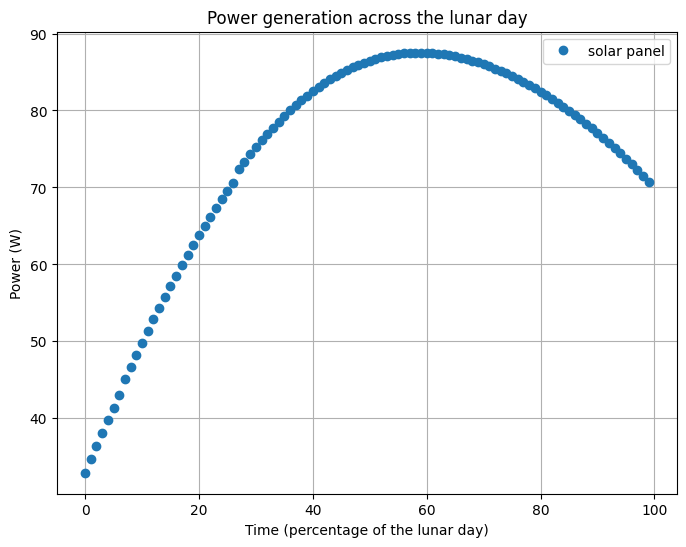

In [20]:
plt.figure(figsize=(8, 6))
plt.plot(power_produced, 'o', label='solar panel')
plt.title('Power generation across the lunar day')
plt.ylabel('Power (W)')
plt.xlabel('Time (percentage of the lunar day)')
plt.legend()
plt.grid(True)
plt.show()